# Split Data & Tokenizer

Tahapan dalam proses ini:
1. Split data 90:10 menggunakan **Iterative Stratification** (MultilabelStratifiedShuffleSplit)
2. Eksplorasi distribusi label setelah split
3. Membuat label biner untuk Task 1 & dataset per task (Task 2–5)
4. Fit **Keras Tokenizer** dari data train
5. Simpan semua dataset dan tokenizer ke Google Drive

---
**Penggunaan Iterative Stratification**  
Dataset ini bersifat multilabel (satu ulasan bisa memiliki beberapa aspek sekaligus). Stratified split biasa tidak bisa menangani multilabel. Iterative Stratification menjamin proporsi setiap kombinasi label terjaga di train dan test.

---
**Label per Task:**
| Task | Label |
|---|---|
| Task 1 — Klasifikasi Aspek | 0 = None (tidak dibahas), 1 = Dibahas (Pos atau Neg) |
| Task 2–5 — Klasifikasi Sentimen | 0 = Negative, 1 = Positive (None dibuang) |

---
**Input :** `dataset_for_modeling.csv`  
**Output:** `df_train_full`, `df_test_full`, dataset per task, `tokenizer_non_stemmed.pkl`, `tokenizer_stemmed.pkl`

## 1. Instalasi & Import Library

In [ ]:
!pip install iterative-stratification --quiet

import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from google.colab import drive
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from tensorflow.keras.preprocessing.text import Tokenizer

pd.set_option('display.max_columns', None)
print("Library berhasil diimport.")

Library berhasil diimport.


## 2. Mount Google Drive & Konfigurasi

In [ ]:
drive.mount('/content/drive')

INPUT_FILE   = '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Text_Preprocessing/dataset_for_modeling.csv'
OUTPUT_DIR   = '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_SplitData/'
TOKEN_DIR    = '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Tokenizer/'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(TOKEN_DIR,  exist_ok=True)

print("Konfigurasi selesai.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Konfigurasi selesai.


## 3. Load Dataset

In [ ]:
df = pd.read_csv(INPUT_FILE, keep_default_na=False)
print(f"Dataset loaded: {df.shape[0]:,} baris, {df.shape[1]} kolom")
print(f"Kolom: {df.columns.tolist()}")

# Pastikan teks tidak kosong
df['review_non_stemmed'] = df['review_non_stemmed'].fillna('').astype(str)
df['review_stemmed']  = df['review_stemmed'].fillna('').astype(str)

print(f"\nDistribusi label sebelum split:")
for col in ['Room', 'Hotel', 'Location', 'Service']:
    print(f"  {col}: {df[col].value_counts().to_dict()}")

Dataset loaded: 7,821 baris, 8 kolom
Kolom: ['id', 'review_text_translated', 'review_non_stemmed', 'review_stemmed', 'Room', 'Hotel', 'Location', 'Service']

Distribusi label sebelum split:
  Room: {'None': 4414, 'Negative': 1812, 'Positive': 1595}
  Hotel: {'None': 4540, 'Positive': 2001, 'Negative': 1280}
  Location: {'None': 5179, 'Positive': 2039, 'Negative': 603}
  Service: {'None': 5042, 'Positive': 1784, 'Negative': 995}


## 4. Persiapan Label untuk Iterative Stratification

MultilabelStratifiedShuffleSplit hanya menerima nilai **biner (0 dan 1)**.
Label `Positive`, `Negative`, `None` dikonversi menjadi 8 kolom biner:

```
Room_Pos, Room_Neg, Hotel_Pos, Hotel_Neg,
Location_Pos, Location_Neg, Service_Pos, Service_Neg
```

Kolom biner ini **hanya untuk keperluan stratifikasi**, bukan label training model.

In [ ]:
# Buat 8 kolom biner untuk stratifikasi
for col in ['Room', 'Hotel', 'Location', 'Service']:
    df[f'{col}_Pos'] = (df[col] == 'Positive').astype(int)
    df[f'{col}_Neg'] = (df[col] == 'Negative').astype(int)

kolom_biner = [f'{col}_{s}' for col in ['Room', 'Hotel', 'Location', 'Service'] for s in ['Pos', 'Neg']]

print("8 kolom biner untuk stratifikasi:")
print(f"  {kolom_biner}")
print(f"\nContoh 5 baris:")
display(df[['Room', 'Hotel', 'Location', 'Service'] + kolom_biner].head())

8 kolom biner untuk stratifikasi:
  ['Room_Pos', 'Room_Neg', 'Hotel_Pos', 'Hotel_Neg', 'Location_Pos', 'Location_Neg', 'Service_Pos', 'Service_Neg']

Contoh 5 baris:


,Room,Hotel,Location,Service,Room_Pos,Room_Neg,Hotel_Pos,Hotel_Neg,Location_Pos,Location_Neg,Service_Pos,Service_Neg
0,Positive,Positive,None,None,1,0,1,0,0,0,0,0
1,None,None,None,Positive,0,0,0,0,0,0,1,0
2,None,Positive,None,None,0,0,1,0,0,0,0,0
3,Positive,Positive,None,None,1,0,1,0,0,0,0,0
4,Negative,None,None,None,0,1,0,0,0,0,0,0


## 5. Split Data 90:10 — Iterative Stratification

In [ ]:
X = df.index.values
y = df[kolom_biner].values

msss = MultilabelStratifiedShuffleSplit(
    n_splits   = 1,
    test_size  = 0.1,
    random_state = 42
)

for train_idx, test_idx in msss.split(X, y):
    df_train = df.iloc[train_idx].reset_index(drop=True)
    df_test  = df.iloc[test_idx].reset_index(drop=True)

print(f"Total data  : {len(df):,}")
print(f"Train (90%) : {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)")
print(f"Test  (10%) : {len(df_test):,}  ({len(df_test)/len(df)*100:.1f}%)")

Total data  : 7,821
Train (90%) : 7,026 (89.8%)
Test  (10%) : 795  (10.2%)


## 6. Eksplorasi Distribusi Label Setelah Split

Verifikasi bahwa proporsi label di train dan test terjaga setelah Iterative Stratification.

In [ ]:
# Tabel perbandingan distribusi label train vs test
# Persentase: dari total masing-masing label (bukan dari total train/test) Contoh: Room Positive ada 1800 total → train=90%, test=10%
print("Distribusi label per aspek (Train vs Test):")
print("-" * 70)

rows = []
for col in ['Room', 'Hotel', 'Location', 'Service']:
    for label in ['Positive', 'Negative', 'None']:
        n_train = (df_train[col] == label).sum()
        n_test  = (df_test[col]  == label).sum()
        total   = n_train + n_test
        rows.append({
            'Aspek'    : col,
            'Label'    : label,
            'Train (n)': n_train,
            'Train (%)': f'{n_train/total*100:.1f}%' if total > 0 else '0%',
            'Test (n)' : n_test,
            'Test (%)'  : f'{n_test/total*100:.1f}%'  if total > 0 else '0%',
            'Total'    : total,
        })

display(pd.DataFrame(rows))

Distribusi label per aspek (Train vs Test):
----------------------------------------------------------------------


,Aspek,Label,Train (n),Train (%),Test (n),Test (%),Total
0,Room,Positive,1435,90.0%,160,10.0%,1595
1,Room,Negative,1631,90.0%,181,10.0%,1812
2,Room,None,3960,89.7%,454,10.3%,4414
3,Hotel,Positive,1801,90.0%,200,10.0%,2001
4,Hotel,Negative,1152,90.0%,128,10.0%,1280
5,Hotel,None,4073,89.7%,467,10.3%,4540
6,Location,Positive,1835,90.0%,204,10.0%,2039
7,Location,Negative,543,90.0%,60,10.0%,603
8,Location,None,4648,89.7%,531,10.3%,5179
9,Service,Positive,1605,90.0%,179,10.0%,1784


In [ ]:
print(df_train.columns.tolist())

['id', 'review_text_translated', 'review_non_stemmed', 'review_stemmed', 'Room', 'Hotel', 'Location', 'Service', 'Room_Pos', 'Room_Neg', 'Hotel_Pos', 'Hotel_Neg', 'Location_Pos', 'Location_Neg', 'Service_Pos', 'Service_Neg']


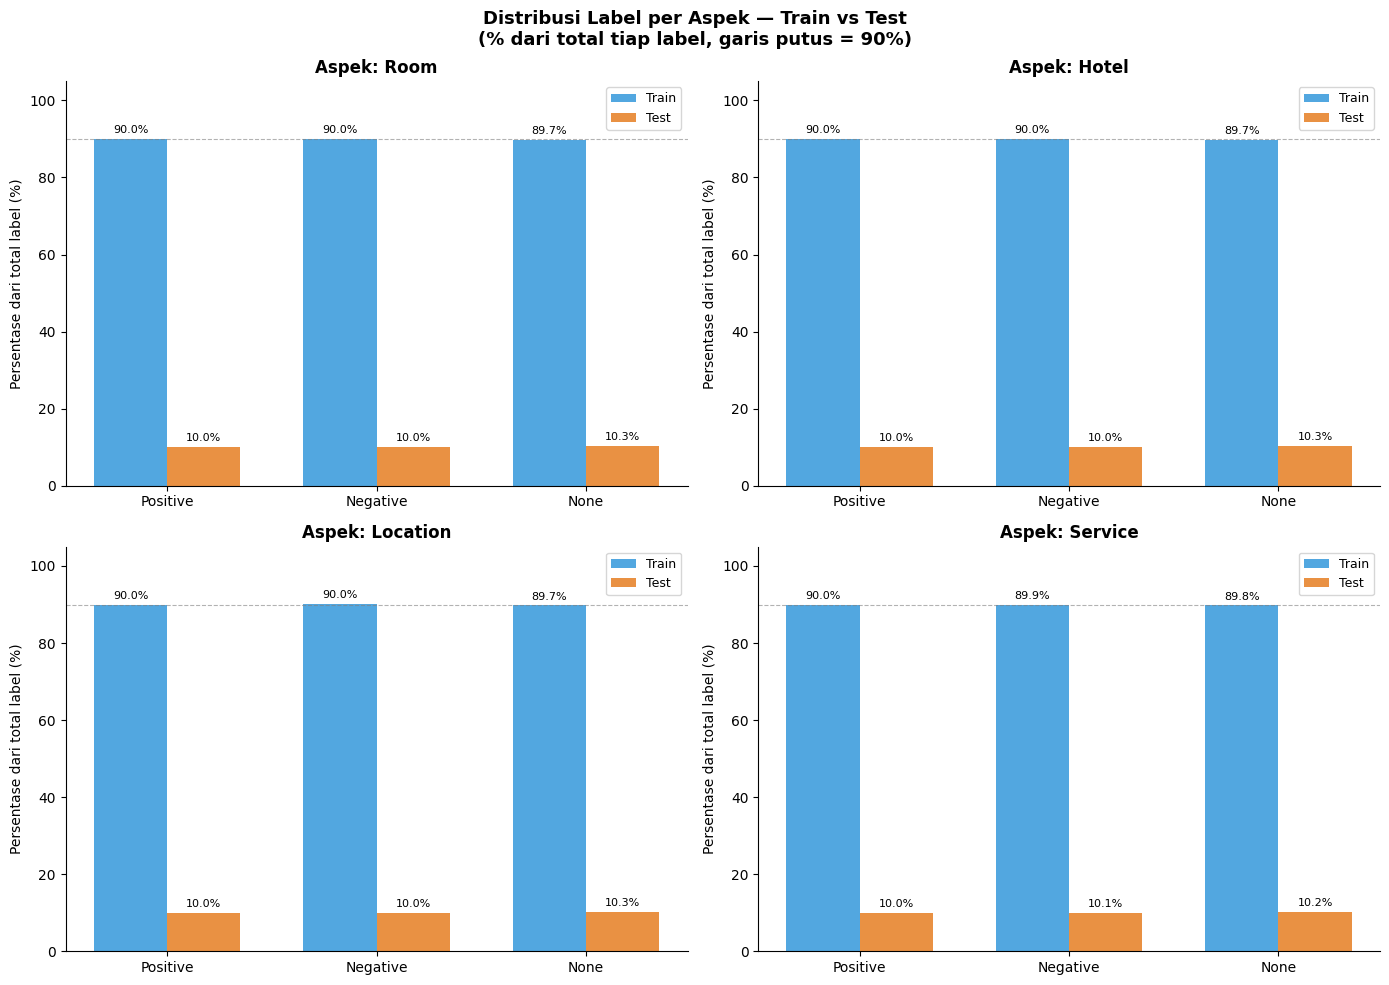

Grafik disimpan.


In [ ]:
# Visualisasi distribusi label (Positive/Negative/None) di train vs test per aspek
# Persentase dihitung dari total masing-masing label (bukan dari total train/test) cek apakah setiap label terbagi ~90% train dan ~10% test

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), ['Room', 'Hotel', 'Location', 'Service']):
    labels = ['Positive', 'Negative', 'None']
    colors = ['#2ecc71', '#e74c3c', '#95a5a6']

    x     = np.arange(len(labels))
    width = 0.35

    train_pct = []
    test_pct  = []
    for label in labels:
        n_train = (df_train[col] == label).sum()
        n_test  = (df_test[col]  == label).sum()
        total   = n_train + n_test
        train_pct.append(n_train / total * 100 if total > 0 else 0)
        test_pct.append( n_test  / total * 100 if total > 0 else 0)

    bars1 = ax.bar(x - width/2, train_pct, width, label='Train', color='#3498db', alpha=0.85)
    bars2 = ax.bar(x + width/2, test_pct,  width, label='Test',  color='#e67e22', alpha=0.85)

    ax.set_title(f'Aspek: {col}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Persentase dari total label (%)')
    ax.set_ylim(0, 105)
    ax.axhline(y=90, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    'Distribusi Label per Aspek — Train vs Test\n'
    '(% dari total tiap label, garis putus = 90%)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'distribusi_label_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan.")


## 7. Buat Label Task 1 & Dataset per Task

Encoding label dilakukan untuk tahap training dan pemodelan selanjutnya

---

**Task 1 — Klasifikasi Aspek Multilabel:**

Label dikonversi menjadi biner per aspek:
- `0` = None → aspek tidak dibahas
- `1` = Dibahas → aspek dibahas (entah Positive atau Negative)

Hasilnya disimpan di kolom: `Room_label`, `Hotel_label`, `Location_label`, `Service_label`

---

**Task 2–5 — Klasifikasi Sentimen per Aspek:**

Filter hanya baris `Positive` dan `Negative` (buang `None`), lalu encode:
- `0` = Negative
- `1` = Positive

Hasilnya disimpan di kolom: `Room_sentiment`, `Hotel_sentiment`, `Location_sentiment`, `Service_sentiment`

---

Data test **tidak di-oversample** — harus mencerminkan distribusi nyata.

In [ ]:
# ============================================================
# TASK 1 — Buat kolom label biner per aspek
# 1 = aspek dibahas (Positive atau Negative)
# 0 = aspek tidak dibahas (None)
# ============================================================
for col in ['Room', 'Hotel', 'Location', 'Service']:
    df_train[f'{col}_label'] = (df_train[col] != 'None').astype(int)
    df_test[f'{col}_label']  = (df_test[col]  != 'None').astype(int)

print("Task 1 — Label biner per aspek:")
print("  0 = None (aspek tidak dibahas)")
print("  1 = Dibahas (Positive atau Negative)")
print()
print("Contoh hasil encoding Task 1 (5 baris pertama df_train):")
display(df_train[['Room', 'Hotel', 'Location', 'Service',
                   'Room_label', 'Hotel_label',
                   'Location_label', 'Service_label']].head(5))

print()
print("Distribusi Task 1 (Train):")
for col in ['Room', 'Hotel', 'Location', 'Service']:
    n1 = (df_train[f'{col}_label'] == 1).sum()
    n0 = (df_train[f'{col}_label'] == 0).sum()
    print(f"  {col}_label: Dibahas(1)={n1:,} ({n1/len(df_train)*100:.1f}%) | "
          f"Tidak Dibahas(0)={n0:,} ({n0/len(df_train)*100:.1f}%)")

print()
print("Distribusi Task 1 (Test):")
for col in ['Room', 'Hotel', 'Location', 'Service']:
    n1 = (df_test[f'{col}_label'] == 1).sum()
    n0 = (df_test[f'{col}_label'] == 0).sum()
    print(f"  {col}_label: Dibahas(1)={n1:,} ({n1/len(df_test)*100:.1f}%) | "
          f"Tidak Dibahas(0)={n0:,} ({n0/len(df_test)*100:.1f}%)")

print()
print("-" * 60)

# ============================================================
# TASK 2-5 — Filter per aspek + encode sentimen
# Filter: hanya Positive dan Negative (buang None)
# Encoding: Negative=0, Positive=1
# ============================================================
task_info = {
    'Task2_Room'    : 'Room',
    'Task3_Hotel'   : 'Hotel',
    'Task4_Location': 'Location',
    'Task5_Service' : 'Service',
}

datasets = {}
print("\nTask 2-5 — Klasifikasi Sentimen per Aspek:")
print("  Filter: hanya Positive dan Negative (None dibuang)")
print("  Encoding: Negative=0, Positive=1")
print("-" * 60)

for task_name, col in task_info.items():
    train_task = df_train[df_train[col].isin(['Positive', 'Negative'])].copy().reset_index(drop=True)
    test_task  = df_test[df_test[col].isin(['Positive', 'Negative'])].copy().reset_index(drop=True)

    train_task[f'{col}_sentiment'] = train_task[col].map({'Negative': 0, 'Positive': 1})
    test_task[f'{col}_sentiment']  = test_task[col].map({'Negative': 0, 'Positive': 1})

    datasets[task_name] = {'train': train_task, 'test': test_task}

    pct_train = len(train_task) / (len(train_task) + len(test_task)) * 100
    pct_test  = len(test_task)  / (len(train_task) + len(test_task)) * 100
    nan_train = train_task[f'{col}_sentiment'].isna().sum()
    nan_test  = test_task[f'{col}_sentiment'].isna().sum()
    status    = 'OK' if nan_train == 0 and nan_test == 0 else 'ADA NaN!'

    print(f"\n  {task_name} ({col}):")
    print(f"    Train: {len(train_task):,} ({pct_train:.1f}%) | Test: {len(test_task):,} ({pct_test:.1f}%)")
    print(f"    Train — Positive(1): {(train_task[f'{col}_sentiment']==1).sum():,} | "
          f"Negative(0): {(train_task[f'{col}_sentiment']==0).sum():,}")
    print(f"    Test  — Positive(1): {(test_task[f'{col}_sentiment']==1).sum():,} | "
          f"Negative(0): {(test_task[f'{col}_sentiment']==0).sum():,}")
    print(f"    Cek NaN [{status}]")

# Tabel contoh output untuk semua task
print()
print("=" * 60)
for task_name, col in task_info.items():
    print(f"\nContoh encoding {task_name} — Aspek {col} (5 baris pertama train):")
    display(datasets[task_name]['train'][[col, f'{col}_sentiment']].head(5))

Task 1 — Label biner per aspek:
  0 = None (aspek tidak dibahas)
  1 = Dibahas (Positive atau Negative)

Contoh hasil encoding Task 1 (5 baris pertama df_train):


,Room,Hotel,Location,Service,Room_label,Hotel_label,Location_label,Service_label
0,Positive,Positive,None,None,1,1,0,0
1,None,None,None,Positive,0,0,0,1
2,None,Positive,None,None,0,1,0,0
3,Positive,Positive,None,None,1,1,0,0
4,None,None,None,Positive,0,0,0,1



Distribusi Task 1 (Train):
  Room_label: Dibahas(1)=3,066 (43.6%) | Tidak Dibahas(0)=3,960 (56.4%)
  Hotel_label: Dibahas(1)=2,953 (42.0%) | Tidak Dibahas(0)=4,073 (58.0%)
  Location_label: Dibahas(1)=2,378 (33.8%) | Tidak Dibahas(0)=4,648 (66.2%)
  Service_label: Dibahas(1)=2,500 (35.6%) | Tidak Dibahas(0)=4,526 (64.4%)

Distribusi Task 1 (Test):
  Room_label: Dibahas(1)=341 (42.9%) | Tidak Dibahas(0)=454 (57.1%)
  Hotel_label: Dibahas(1)=328 (41.3%) | Tidak Dibahas(0)=467 (58.7%)
  Location_label: Dibahas(1)=264 (33.2%) | Tidak Dibahas(0)=531 (66.8%)
  Service_label: Dibahas(1)=279 (35.1%) | Tidak Dibahas(0)=516 (64.9%)

------------------------------------------------------------

Task 2-5 — Klasifikasi Sentimen per Aspek:
  Filter: hanya Positive dan Negative (None dibuang)
  Encoding: Negative=0, Positive=1
------------------------------------------------------------

  Task2_Room (Room):
    Train: 3,066 (90.0%) | Test: 341 (10.0%)
    Train — Positive(1): 1,435 | Negative(0): 1

,Room,Room_sentiment
0,Positive,1
1,Positive,1
2,Positive,1
3,Positive,1
4,Negative,0



Contoh encoding Task3_Hotel — Aspek Hotel (5 baris pertama train):


,Hotel,Hotel_sentiment
0,Positive,1
1,Positive,1
2,Positive,1
3,Positive,1
4,Positive,1



Contoh encoding Task4_Location — Aspek Location (5 baris pertama train):


,Location,Location_sentiment
0,Positive,1
1,Positive,1
2,Positive,1
3,Positive,1
4,Positive,1



Contoh encoding Task5_Service — Aspek Service (5 baris pertama train):


,Service,Service_sentiment
0,Positive,1
1,Positive,1
2,Negative,0
3,Positive,1
4,Positive,1


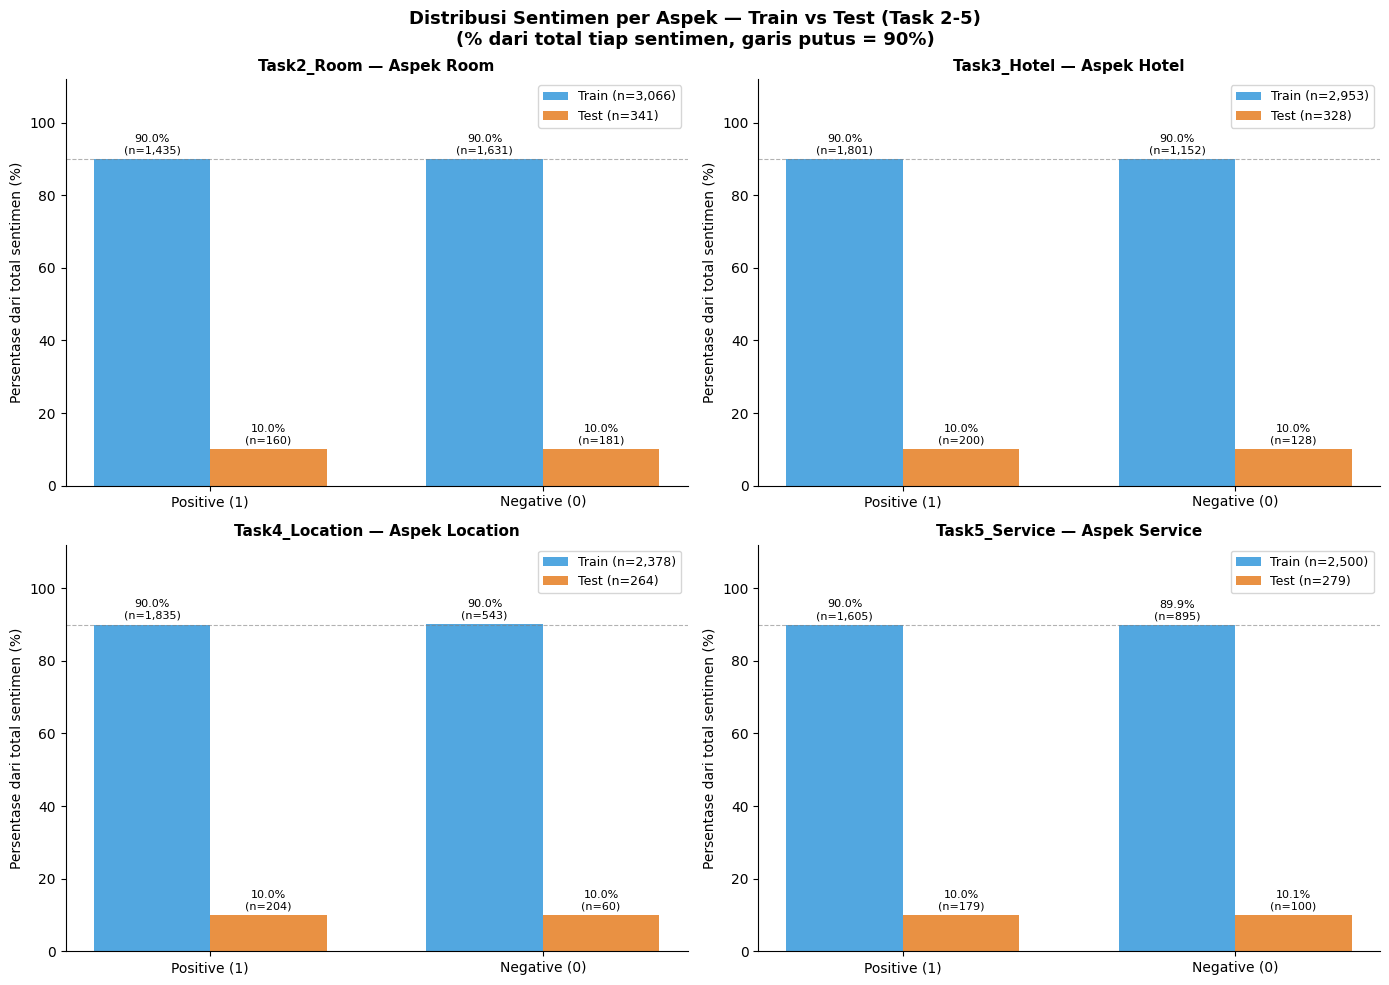

Grafik disimpan.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (task_name, col) in zip(axes.flatten(), task_info.items()):
    train_task = datasets[task_name]['train']
    test_task  = datasets[task_name]['test']
    sent_col   = f'{col}_sentiment'

    labels      = [1, 0]
    label_names = ['Positive (1)', 'Negative (0)']

    x     = np.arange(len(labels))
    width = 0.35

    train_n   = []
    test_n    = []
    train_pct = []
    test_pct  = []
    for lbl in labels:
        n_train = (train_task[sent_col] == lbl).sum()
        n_test  = (test_task[sent_col]  == lbl).sum()
        total   = n_train + n_test
        train_n.append(n_train)
        test_n.append(n_test)
        train_pct.append(n_train / total * 100 if total > 0 else 0)
        test_pct.append( n_test  / total * 100 if total > 0 else 0)

    bars1 = ax.bar(x - width/2, train_pct, width,
                   label=f'Train (n={len(train_task):,})', color='#3498db', alpha=0.85)
    bars2 = ax.bar(x + width/2, test_pct,  width,
                   label=f'Test (n={len(test_task):,})',  color='#e67e22', alpha=0.85)

    ax.set_title(f'{task_name} — Aspek {col}', fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(label_names)
    ax.set_ylabel('Persentase dari total sentimen (%)')
    ax.set_ylim(0, 112)
    ax.axhline(y=90, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    # Label di atas bar: persentase + jumlah
    for bar, n in zip(bars1, train_n):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%\n(n={n:,})',
                ha='center', va='bottom', fontsize=8)
    for bar, n in zip(bars2, test_n):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%\n(n={n:,})',
                ha='center', va='bottom', fontsize=8)

plt.suptitle(
    'Distribusi Sentimen per Aspek — Train vs Test (Task 2-5)\n'
    '(% dari total tiap sentimen, garis putus = 90%)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'distribusi_sentimen_per_task.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan.")

In [ ]:
import pandas as pd

# TABEL 1 — Distribusi Label Task 1
print("TABEL 1 — Distribusi Label Task 1 (0=Tidak Dibahas, 1=Dibahas)")
print("Persentase: berapa % dari total label tersebut ada di train vs test")
print("-" * 75)

rows_task1 = []
for col in ['Room', 'Hotel', 'Location', 'Service']:
    label_col = f'{col}_label'
    for label_val, label_nama in [(0, 'Tidak Dibahas'), (1, 'Dibahas')]:
        n_train = (df_train[label_col] == label_val).sum()
        n_test  = (df_test[label_col]  == label_val).sum()
        total   = n_train + n_test
        rows_task1.append({
            'Aspek'    : col,
            'Label'    : f'{label_val} ({label_nama})',
            'Train (n)': n_train,
            'Train (%)': f'{n_train/total*100:.1f}%',
            'Test (n)' : n_test,
            'Test (%)'  : f'{n_test/total*100:.1f}%',
            'Total'    : total,
        })
display(pd.DataFrame(rows_task1))

# TABEL 2 — Total Membahas vs Tidak per Aspek
print("\nTABEL 2 — Total Ulasan Membahas vs Tidak per Aspek (seluruh data)")
print("-" * 65)

df_all     = pd.concat([df_train, df_test], ignore_index=True)
rows_task2 = []
for col in ['Room', 'Hotel', 'Location', 'Service']:
    label_col = f'{col}_label'
    n_dibahas = (df_all[label_col] == 1).sum()
    n_tidak   = (df_all[label_col] == 0).sum()
    total     = len(df_all)
    rows_task2.append({
        'Aspek'             : col,
        'Dibahas (1)'       : n_dibahas,
        'Dibahas (%)'       : f'{n_dibahas/total*100:.1f}%',
        'Tidak Dibahas (0)' : n_tidak,
        'Tidak Dibahas (%)' : f'{n_tidak/total*100:.1f}%',
    })
display(pd.DataFrame(rows_task2))

# TABEL 3 — Distribusi Sentimen per Aspek
# Diambil dari datasets (hasil filter) bukan df_train langsung
print("\nTABEL 3 — Distribusi Sentimen per Aspek (0=Negative, 1=Positive)")
print("Persentase: berapa % dari total sentimen tersebut ada di train vs test")
print("-" * 75)

rows_task3 = []
for task_name, col in task_info.items():
    sent_col   = f'{col}_sentiment'
    train_task = datasets[task_name]['train']
    test_task  = datasets[task_name]['test']

    for label_val, label_nama in [(1, 'Positive'), (0, 'Negative')]:
        n_train = (train_task[sent_col] == label_val).sum()
        n_test  = (test_task[sent_col]  == label_val).sum()
        total   = n_train + n_test
        rows_task3.append({
            'Aspek'    : col,
            'Sentimen' : f'{label_val} ({label_nama})',
            'Train (n)': n_train,
            'Train (%)': f'{n_train/total*100:.1f}%' if total > 0 else '0%',
            'Test (n)' : n_test,
            'Test (%)'  : f'{n_test/total*100:.1f}%'  if total > 0 else '0%',
            'Total'    : total,
        })
display(pd.DataFrame(rows_task3))

TABEL 1 — Distribusi Label Task 1 (0=Tidak Dibahas, 1=Dibahas)
Persentase: berapa % dari total label tersebut ada di train vs test
---------------------------------------------------------------------------


,Aspek,Label,Train (n),Train (%),Test (n),Test (%),Total
0,Room,0 (Tidak Dibahas),3960,89.7%,454,10.3%,4414
1,Room,1 (Dibahas),3066,90.0%,341,10.0%,3407
2,Hotel,0 (Tidak Dibahas),4073,89.7%,467,10.3%,4540
3,Hotel,1 (Dibahas),2953,90.0%,328,10.0%,3281
4,Location,0 (Tidak Dibahas),4648,89.7%,531,10.3%,5179
5,Location,1 (Dibahas),2378,90.0%,264,10.0%,2642
6,Service,0 (Tidak Dibahas),4526,89.8%,516,10.2%,5042
7,Service,1 (Dibahas),2500,90.0%,279,10.0%,2779



TABEL 2 — Total Ulasan Membahas vs Tidak per Aspek (seluruh data)
-----------------------------------------------------------------


,Aspek,Dibahas (1),Dibahas (%),Tidak Dibahas (0),Tidak Dibahas (%)
0,Room,3407,43.6%,4414,56.4%
1,Hotel,3281,42.0%,4540,58.0%
2,Location,2642,33.8%,5179,66.2%
3,Service,2779,35.5%,5042,64.5%



TABEL 3 — Distribusi Sentimen per Aspek (0=Negative, 1=Positive)
Persentase: berapa % dari total sentimen tersebut ada di train vs test
---------------------------------------------------------------------------


,Aspek,Sentimen,Train (n),Train (%),Test (n),Test (%),Total
0,Room,1 (Positive),1435,90.0%,160,10.0%,1595
1,Room,0 (Negative),1631,90.0%,181,10.0%,1812
2,Hotel,1 (Positive),1801,90.0%,200,10.0%,2001
3,Hotel,0 (Negative),1152,90.0%,128,10.0%,1280
4,Location,1 (Positive),1835,90.0%,204,10.0%,2039
5,Location,0 (Negative),543,90.0%,60,10.0%,603
6,Service,1 (Positive),1605,90.0%,179,10.0%,1784
7,Service,0 (Negative),895,89.9%,100,10.1%,995


In [ ]:
# Tabel ringkasan proporsi train/test per task
print("Verifikasi proporsi 90:10 setelah filter per task:")
rows = []
for task_name, col in task_info.items():
    train_task = datasets[task_name]['train']
    test_task  = datasets[task_name]['test']
    total      = len(train_task) + len(test_task)
    rows.append({
        'Task'         : task_name,
        'Total'        : total,
        'Train (n)'    : len(train_task),
        'Train (%)'    : f"{len(train_task)/total*100:.1f}%",
        'Test (n)'     : len(test_task),
        'Test (%)'     : f"{len(test_task)/total*100:.1f}%",
    })
display(pd.DataFrame(rows))

Verifikasi proporsi 90:10 setelah filter per task:


,Task,Total,Train (n),Train (%),Test (n),Test (%)
0,Task2_Room,3407,3066,90.0%,341,10.0%
1,Task3_Hotel,3281,2953,90.0%,328,10.0%
2,Task4_Location,2642,2378,90.0%,264,10.0%
3,Task5_Service,2779,2500,90.0%,279,10.0%


## 8. Simpan Dataset

In [ ]:
# Simpan train & test full (Task 1)
df_train.to_csv(OUTPUT_DIR + 'df_train_full.csv', index=False, encoding='utf-8-sig')
df_test.to_csv( OUTPUT_DIR + 'df_test_full.csv',  index=False, encoding='utf-8-sig')
print(f"Disimpan: df_train_full.csv ({len(df_train):,} baris)")
print(f"Disimpan: df_test_full.csv  ({len(df_test):,} baris)")

# Simpan dataset per task (Task 2–5)
print()
for task_name, col in task_info.items():
    train_path = OUTPUT_DIR + f'df_train_{task_name}.csv'
    test_path  = OUTPUT_DIR + f'df_test_{task_name}.csv'
    datasets[task_name]['train'].to_csv(train_path, index=False, encoding='utf-8-sig')
    datasets[task_name]['test'].to_csv( test_path,  index=False, encoding='utf-8-sig')
    print(f"Disimpan: df_train_{task_name}.csv ({len(datasets[task_name]['train']):,} baris)")
    print(f"Disimpan: df_test_{task_name}.csv  ({len(datasets[task_name]['test']):,} baris)")

Disimpan: df_train_full.csv (7,026 baris)
Disimpan: df_test_full.csv  (795 baris)

Disimpan: df_train_Task2_Room.csv (3,066 baris)
Disimpan: df_test_Task2_Room.csv  (341 baris)
Disimpan: df_train_Task3_Hotel.csv (2,953 baris)
Disimpan: df_test_Task3_Hotel.csv  (328 baris)
Disimpan: df_train_Task4_Location.csv (2,378 baris)
Disimpan: df_test_Task4_Location.csv  (264 baris)
Disimpan: df_train_Task5_Service.csv (2,500 baris)
Disimpan: df_test_Task5_Service.csv  (279 baris)


In [ ]:
import pandas as pd

OUTPUT_DIR = '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_SplitData/'

files = {
    'df_train_full'         : 'df_train_full.csv',
    'df_test_full'          : 'df_test_full.csv',
    'df_train_Task2_Room'   : 'df_train_Task2_Room.csv',
    'df_test_Task2_Room'    : 'df_test_Task2_Room.csv',
    'df_train_Task3_Hotel'  : 'df_train_Task3_Hotel.csv',
    'df_test_Task3_Hotel'   : 'df_test_Task3_Hotel.csv',
    'df_train_Task4_Location': 'df_train_Task4_Location.csv',
    'df_test_Task4_Location' : 'df_test_Task4_Location.csv',
    'df_train_Task5_Service' : 'df_train_Task5_Service.csv',
    'df_test_Task5_Service'  : 'df_test_Task5_Service.csv',
}

for nama, fname in files.items():
    df_cek = pd.read_csv(OUTPUT_DIR + fname, keep_default_na=False)
    print(f"{'='*60}")
    print(f"{nama}")
    print(f"  Shape  : {df_cek.shape[0]:,} baris × {df_cek.shape[1]} kolom")
    print(f"  Kolom  : {df_cek.columns.tolist()}")
    print(f"  Index  : {df_cek.index.tolist()[:5]} ...")
    if 'id' in df_cek.columns:
        print(f"  ID (5) : {df_cek['id'].tolist()[:5]}")
    print()
    display(df_cek.head(3))
    print()

df_train_full
  Shape  : 7,026 baris × 20 kolom
  Kolom  : ['id', 'review_text_translated', 'review_non_stemmed', 'review_stemmed', 'Room', 'Hotel', 'Location', 'Service', 'Room_Pos', 'Room_Neg', 'Hotel_Pos', 'Hotel_Neg', 'Location_Pos', 'Location_Neg', 'Service_Pos', 'Service_Neg', 'Room_label', 'Hotel_label', 'Location_label', 'Service_label']
  Index  : [0, 1, 2, 3, 4] ...
  ID (5) : [1, 2, 3, 4, 7]



,id,review_text_translated,review_non_stemmed,review_stemmed,Room,Hotel,Location,Service,Room_Pos,Room_Neg,Hotel_Pos,Hotel_Neg,Location_Pos,Location_Neg,Service_Pos,Service_Neg,Room_label,Hotel_label,Location_label,Service_label
0,1,Pertama kali disini super kagum sama interior ...,super kagum interior hotel authentic banget ka...,super kagum interior hotel authentic banget ka...,Positive,Positive,None,None,1,0,1,0,0,0,0,0,1,1,0,0
1,2,Pelayanan oke banget dibantu dengan resepsioni...,pelayanan oke banget dibantu resepsionis sanga...,layan oke banget bantu resepsionis sangat rama...,None,None,None,Positive,0,0,0,0,0,0,1,0,0,0,0,1
2,3,Kolam renang dan gym nya sangat bagus dan yang...,kolam renang gym sangat bagus terbaik hotel,kolam renang gym sangat bagus baik hotel,None,Positive,None,None,0,0,1,0,0,0,0,0,0,1,0,0



df_test_full
  Shape  : 795 baris × 20 kolom
  Kolom  : ['id', 'review_text_translated', 'review_non_stemmed', 'review_stemmed', 'Room', 'Hotel', 'Location', 'Service', 'Room_Pos', 'Room_Neg', 'Hotel_Pos', 'Hotel_Neg', 'Location_Pos', 'Location_Neg', 'Service_Pos', 'Service_Neg', 'Room_label', 'Hotel_label', 'Location_label', 'Service_label']
  Index  : [0, 1, 2, 3, 4] ...
  ID (5) : [5, 6, 10, 11, 35]



,id,review_text_translated,review_non_stemmed,review_stemmed,Room,Hotel,Location,Service,Room_Pos,Room_Neg,Hotel_Pos,Hotel_Neg,Location_Pos,Location_Neg,Service_Pos,Service_Neg,Room_label,Hotel_label,Location_label,Service_label
0,5,Perbotan kamar seperti AC dan dispenser air mi...,perbotan kamar ac dispenser air minum sering t...,bot kamar ac dispenser air minum sering tidak ...,Negative,None,None,None,0,1,0,0,0,0,0,0,1,0,0,0
1,6,Dekorasinya sangat bagus tentang sejarah. Apal...,dekorasinya sangat bagus sejarah lukisan berse...,dekorasi sangat bagus sejarah lukis sejarah,None,Positive,None,None,0,0,1,0,0,0,0,0,0,1,0,0
2,10,"Pelayanan buruk, saya dibiarkan menurunkan bar...",pelayanan buruk dibiarkan menurunkan barang mo...,layan buruk biar turun barang mobil staf,None,None,None,Negative,0,0,0,0,0,0,0,1,0,0,0,1



df_train_Task2_Room
  Shape  : 3,066 baris × 21 kolom
  Kolom  : ['id', 'review_text_translated', 'review_non_stemmed', 'review_stemmed', 'Room', 'Hotel', 'Location', 'Service', 'Room_Pos', 'Room_Neg', 'Hotel_Pos', 'Hotel_Neg', 'Location_Pos', 'Location_Neg', 'Service_Pos', 'Service_Neg', 'Room_label', 'Hotel_label', 'Location_label', 'Service_label', 'Room_sentiment']
  Index  : [0, 1, 2, 3, 4] ...
  ID (5) : [1, 4, 12, 14, 16]



...

,id,review_text_translated,review_non_stemmed,review_stemmed,Room,Hotel,Location,Service,Room_Pos,Room_Neg,Hotel_Pos,Hotel_Neg,Location_Pos,Location_Neg,Service_Pos,Service_Neg,Room_label,Hotel_label,Location_label,Service_label,Location_sentiment
0,35,Lokasinya bagus deh. kemana2 sangat dekat. Ooh...,lokasinya bagus kemana sangat dekat staffnya s...,lokasi bagus mana sangat dekat staffnya sangat...,None,None,Positive,Positive,0,0,0,0,1,0,1,0,0,0,1,1,1
1,149,Lokasi bagus poll dekat dengan area perbelanja...,lokasi bagus pol dekat area perbelanjaan pujas...,lokasi bagus pol dekat area belanja pujasera a...,None,None,Positive,None,0,0,0,0,1,0,0,0,0,0,1,0,1
2,191,Kamar bersih dan modern. Dekat dengan Kota Tua...,kamar bersih modern dekat kota tua surabaya en...,kamar bersih modern dekat kota tua surabaya en...,Positive,None,Positive,None,1,0,0,0,1,0,0,0,1,0,1,0,1



df_train_Task5_Service
  Shape  : 2,500 baris × 21 kolom
  Kolom  : ['id', 'review_text_translated', 'review_non_stemmed', 'review_stemmed', 'Room', 'Hotel', 'Location', 'Service', 'Room_Pos', 'Room_Neg', 'Hotel_Pos', 'Hotel_Neg', 'Location_Pos', 'Location_Neg', 'Service_Pos', 'Service_Neg', 'Room_label', 'Hotel_label', 'Location_label', 'Service_label', 'Service_sentiment']
  Index  : [0, 1, 2, 3, 4] ...
  ID (5) : [2, 7, 8, 9, 13]



,id,review_text_translated,review_non_stemmed,review_stemmed,Room,Hotel,Location,Service,Room_Pos,Room_Neg,Hotel_Pos,Hotel_Neg,Location_Pos,Location_Neg,Service_Pos,Service_Neg,Room_label,Hotel_label,Location_label,Service_label,Service_sentiment
0,2,Pelayanan oke banget dibantu dengan resepsioni...,pelayanan oke banget dibantu resepsionis sanga...,layan oke banget bantu resepsionis sangat rama...,None,None,None,Positive,0,0,0,0,0,0,1,0,0,0,0,1,1
1,7,Staf sangat ramah dan mengajak kami berkelilin...,staf sangat ramah mengajak berkeliling hotel m...,staf sangat ramah ajak keliling hotel cerita s...,None,None,None,Positive,0,0,0,0,0,0,1,0,0,0,0,1,1
2,8,staf didominasi oleh anak magang mengakibatkan...,staf didominasi anak magang mengakibatkan pela...,staf dominasi anak magang akibat layan tidak k...,None,None,None,Negative,0,0,0,0,0,0,0,1,0,0,0,1,0



df_test_Task5_Service
  Shape  : 279 baris × 21 kolom
  Kolom  : ['id', 'review_text_translated', 'review_non_stemmed', 'review_stemmed', 'Room', 'Hotel', 'Location', 'Service', 'Room_Pos', 'Room_Neg', 'Hotel_Pos', 'Hotel_Neg', 'Location_Pos', 'Location_Neg', 'Service_Pos', 'Service_Neg', 'Room_label', 'Hotel_label', 'Location_label', 'Service_label', 'Service_sentiment']
  Index  : [0, 1, 2, 3, 4] ...
  ID (5) : [10, 11, 35, 55, 56]



,id,review_text_translated,review_non_stemmed,review_stemmed,Room,Hotel,Location,Service,Room_Pos,Room_Neg,Hotel_Pos,Hotel_Neg,Location_Pos,Location_Neg,Service_Pos,Service_Neg,Room_label,Hotel_label,Location_label,Service_label,Service_sentiment
0,10,"Pelayanan buruk, saya dibiarkan menurunkan bar...",pelayanan buruk dibiarkan menurunkan barang mo...,layan buruk biar turun barang mobil staf,None,None,None,Negative,0,0,0,0,0,0,0,1,0,0,0,1,0
1,11,Staffnya sangat membantu Dan Sabar menjelaskan...,staffnya sangat membantu sabar hotel sangat ny...,staffnya sangat bantu sabar hotel sangat nyama...,None,Positive,None,Positive,0,0,1,0,0,0,1,0,0,1,0,1,1
2,35,Lokasinya bagus deh. kemana2 sangat dekat. Ooh...,lokasinya bagus kemana sangat dekat staffnya s...,lokasi bagus mana sangat dekat staffnya sangat...,None,None,Positive,Positive,0,0,0,0,1,0,1,0,0,0,1,1,1


## 9. Tokenizer

Tokenizer difit **hanya dari data train** (df_train_full) untuk mencegah data leakage dari test set.

Dibuat 2 tokenizer:
- `tokenizer_non_stemmed` → dari kolom `review_non_stemmed`
- `tokenizer_stemmed` → dari kolom `review_stemmed`

Kedua tokenizer ini dipakai konsisten untuk semua skenario (Word2Vec maupun FastText) karena teks inputnya sama — hanya model embeddingnya yang berbeda.

In [ ]:
# Tokenizer Non-Stemmed
tokenizer_nonstem = Tokenizer(oov_token='<OOV>')
tokenizer_nonstem.fit_on_texts(df_train['review_non_stemmed'])

vocab_size_nonstem = len(tokenizer_nonstem.word_index) + 1  # +1 untuk padding index 0

print("Tokenizer Non-Stemmed:")
print(f"  Vocabulary size : {vocab_size_nonstem:,} kata (termasuk <OOV> dan padding)")
print(f"  Difit dari      : {len(df_train):,} data train")

# Contoh tokenisasi
contoh_teks  = df_train['review_non_stemmed'].iloc[0]
contoh_seq   = tokenizer_nonstem.texts_to_sequences([contoh_teks])[0]
print(f"\nContoh teks    : {contoh_teks[:80]}")
print(f"Contoh indeks  : {contoh_seq[:15]}...")

Tokenizer Non-Stemmed:
  Vocabulary size : 5,546 kata (termasuk <OOV> dan padding)
  Difit dari      : 7,026 data train

Contoh teks    : super kagum interior hotel authentic banget kamarnya nyaman televisi besar bange
Contoh indeks  : [432, 968, 240, 4, 3241, 19, 14, 12, 124, 69, 19]...


In [ ]:
# Tokenizer Stemmed
tokenizer_stem = Tokenizer(oov_token='<OOV>')
tokenizer_stem.fit_on_texts(df_train['review_stemmed'])

vocab_size_stem = len(tokenizer_stem.word_index) + 1

print("Tokenizer Stemmed:")
print(f"  Vocabulary size : {vocab_size_stem:,} kata (termasuk <OOV> dan padding)")
print(f"  Difit dari      : {len(df_train):,} data train")

contoh_teks_s = df_train['review_stemmed'].iloc[0]
contoh_seq_s  = tokenizer_stem.texts_to_sequences([contoh_teks_s])[0]
print(f"\nContoh teks    : {contoh_teks_s[:80]}")
print(f"Contoh indeks  : {contoh_seq_s[:15]}...")

Tokenizer Stemmed:
  Vocabulary size : 3,812 kata (termasuk <OOV> dan padding)
  Difit dari      : 7,026 data train

Contoh teks    : super kagum interior hotel authentic banget kamar nyaman televisi besar banget
Contoh indeks  : [413, 737, 191, 4, 2363, 23, 3, 13, 130, 68, 23]...


In [ ]:
# Cek berapa kata test yang OOV (tidak ada di vocabulary train)
print("Cek OOV pada data test:")

for nama, tokenizer, col in [
    ('Non-Stemmed', tokenizer_nonstem, 'review_non_stemmed'),
    ('Stemmed',     tokenizer_stem,  'review_stemmed')
]:
    vocab     = set(tokenizer.word_index.keys())
    semua_kata_test = ' '.join(df_test[col].astype(str)).split()
    oov_kata  = [k for k in semua_kata_test if k not in vocab]
    oov_unik  = set(oov_kata)
    print(f"\n  {nama}:")
    print(f"    Total token test    : {len(semua_kata_test):,}")
    print(f"    Token OOV           : {len(oov_kata):,} ({len(oov_kata)/len(semua_kata_test)*100:.2f}%)")
    print(f"    Kata unik OOV       : {len(oov_unik):,}")
    print(f"    Contoh kata OOV     : {list(oov_unik)[:10]}")

Cek OOV pada data test:

  Non-Stemmed:
    Total token test    : 12,945
    Token OOV           : 278 (2.15%)
    Kata unik OOV       : 266
    Contoh kata OOV     : ['menyalahkannya', 'sydney', 'ketuk', 'tenangnya', 'bermakna', 'segelas', 'okelah', 'adaptor', 'pencar', 'bisingnya']

  Stemmed:
    Total token test    : 12,945
    Token OOV           : 179 (1.38%)
    Kata unik OOV       : 171
    Contoh kata OOV     : ['sydney', 'inspirasi', 'adaptor', 'depresi', 'occupancy', 'im', 'alternatif', 'sheets', 'saraswati', 'ngeri']


In [ ]:
# Simpan tokenizer ke Google Drive
TOKEN_DIR = '/content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Tokenizer/'

with open(TOKEN_DIR + 'tokenizer_nonstem.pkl', 'wb') as f:
    pickle.dump(tokenizer_nonstem, f)

with open(TOKEN_DIR + 'tokenizer_stem.pkl', 'wb') as f:
    pickle.dump(tokenizer_stem, f)

print(f"Tokenizer disimpan:")
print(f"  {TOKEN_DIR}tokenizer_nonstem.pkl")
print(f"  {TOKEN_DIR}tokenizer_stem.pkl")

Tokenizer disimpan:
  /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Tokenizer/tokenizer_nonstem.pkl
  /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Tokenizer/tokenizer_stem.pkl


## 10. Ringkasan

In [ ]:
print("=" * 60)
print("          RINGKASAN SPLIT DATA & TOKENIZER")
print("=" * 60)
print(f"\nTotal data         : {len(df):,} ulasan")
print(f"Train (90%)        : {len(df_train):,} ulasan")
print(f"Test  (10%)        : {len(df_test):,} ulasan")
print(f"Metode split       : Iterative Stratification (MultilabelStratifiedShuffleSplit)")
print(f"\nKolom label yang tersimpan di dataset:")
print(f"  Kolom asli        : Room, Hotel, Location, Service (Positive/Negative/None)")
print(f"  Task 1            : Room_label, Hotel_label, Location_label, Service_label (0/1)")
print(f"  Task 2–5          : Room_sentiment, Hotel_sentiment, dst (0=Neg, 1=Pos)")
print(f"\nDataset per task:")
print(f"  Task 1 (Aspek)   : train={len(df_train):,} | test={len(df_test):,}")
for task_name, col in task_info.items():
    tr = len(datasets[task_name]['train'])
    te = len(datasets[task_name]['test'])
    print(f"  {task_name}: train={tr:,} | test={te:,}")
print(f"\nTokenizer:")
print(f"  Non-Stemmed vocab : {vocab_size_nonstem:,} kata")
print(f"  Stemmed vocab     : {vocab_size_stem:,} kata")
print(f"  Difit dari        : data TRAIN saja")
print(f"\nFile tersimpan di  : {OUTPUT_DIR}")
print(f"Tokenizer di       : {TOKEN_DIR}")
print("=" * 60)

          RINGKASAN SPLIT DATA & TOKENIZER

Total data         : 7,821 ulasan
Train (90%)        : 7,026 ulasan
Test  (10%)        : 795 ulasan
Metode split       : Iterative Stratification (MultilabelStratifiedShuffleSplit)

Kolom label yang tersimpan di dataset:
  Kolom asli        : Room, Hotel, Location, Service (Positive/Negative/None)
  Task 1            : Room_label, Hotel_label, Location_label, Service_label (0/1)
  Task 2–5          : Room_sentiment, Hotel_sentiment, dst (0=Neg, 1=Pos)

Dataset per task:
  Task 1 (Aspek)   : train=7,026 | test=795
  Task2_Room: train=3,066 | test=341
  Task3_Hotel: train=2,953 | test=328
  Task4_Location: train=2,378 | test=264
  Task5_Service: train=2,500 | test=279

Tokenizer:
  Non-Stemmed vocab : 5,546 kata
  Stemmed vocab     : 3,812 kata
  Difit dari        : data TRAIN saja

File tersimpan di  : /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_SplitData/
Tokenizer di       : /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Tokeniz